In [1]:
import pandas as pd
df= pd.read_csv("online_course_completion.csv")

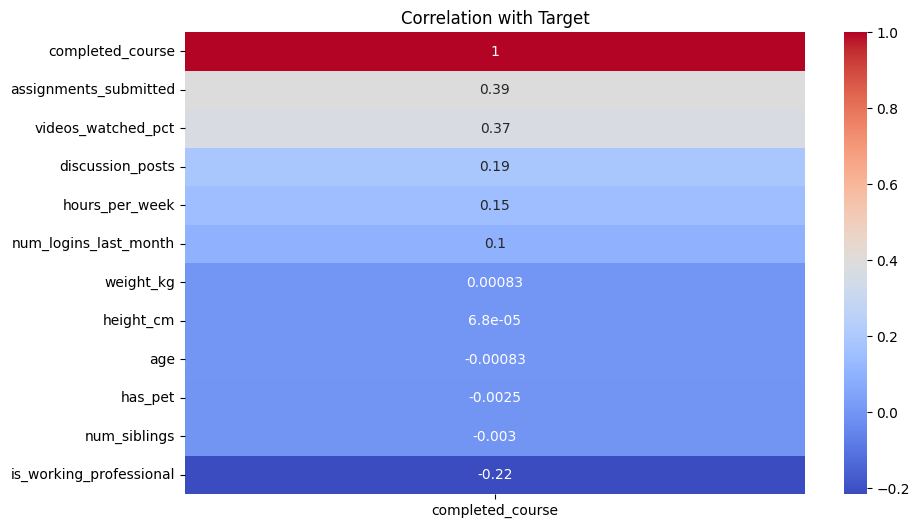

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
corr_matrix = df.corr(numeric_only=True)
plt.figure(figsize=(10,6))
sns.heatmap(corr_matrix[['completed_course']].sort_values(by='completed_course', ascending=False),annot=True,cmap='coolwarm')
plt.title("Correlation with Target")
plt.show()


In [3]:
df=df.drop(['num_siblings','weight_kg','height_cm','age','has_pet'],axis=1,errors='ignore')

In [4]:
df

,continent,country,education_level,hours_per_week,num_logins_last_month,videos_watched_pct,assignments_submitted,discussion_posts,is_working_professional,preferred_device,completed_course,favorite_color,birth_month
0,Asia,Japan,Bachelors,9.116071,23,0.507679,7,1,1,mobile,0,red,May
1,Africa,Kenya,No Formal Education,0.454712,19,0.631424,1,1,1,desktop,0,black,Sep
2,South America,Brazil,Bachelors,4.946724,22,0.424817,2,2,0,console,0,green,Jul
3,Africa,Nigeria,Bachelors,5.053960,24,0.318874,3,0,1,console,0,purple,Jun
4,Asia,India,Bachelors,9.870424,28,1.000000,6,0,0,mobile,1,orange,Nov
...,...,...,...,...,...,...,...,...,...,...,...,...,...
499995,Africa,Nigeria,High School,4.043879,17,0.743042,5,2,1,desktop,0,black,Feb
499996,South America,Brazil,Masters,4.382572,25,0.708222,0,3,1,desktop,0,white,Apr
499997,North America,Mexico,Bachelors,9.374327,24,0.910133,5,2,0,mobile,1,white,Aug
499998,Asia,Singapore,High School,6.968224,18,0.535972,2,1,0,mobile,0,pink,Apr


In [5]:
df.groupby('continent')['completed_course'].mean().sort_values(ascending=False)


continent
South America    0.252682
Europe           0.252588
Asia             0.251269
Africa           0.249822
North America    0.249567
Antarctica       0.102008
Name: completed_course, dtype: float64

In [6]:
df['continent'].value_counts(normalize=True)

continent
Asia             0.260462
Europe           0.259418
North America    0.199706
South America    0.149880
Africa           0.120574
Antarctica       0.009960
Name: proportion, dtype: float64

In [7]:
df=df.drop('continent',axis=1,errors='ignore')

In [8]:
df.groupby('country')['completed_course'].mean().sort_values(ascending=False)


country
Spain            0.256517
Kenya            0.253764
Brazil           0.253331
Argentina        0.253158
Bhutan           0.253041
India            0.252403
Norway           0.251892
France           0.251891
Chile            0.251559
Japan            0.251415
USA              0.250495
Germany          0.250360
Mexico           0.249753
South Africa     0.248860
Canada           0.248441
Singapore        0.248184
Nigeria          0.246823
Atlantis         0.246203
Research_Base    0.102008
Name: completed_course, dtype: float64

In [9]:
df['country'].value_counts(normalize=True)


country
Mexico           0.066890
USA              0.066732
Canada           0.066084
Bhutan           0.065610
India            0.065134
Japan            0.065024
Singapore        0.064694
France           0.064258
Spain            0.064144
Norway           0.063956
Germany          0.063900
Chile            0.050024
Argentina        0.050024
Brazil           0.049832
South Africa     0.040344
Kenya            0.040250
Nigeria          0.039980
Research_Base    0.009960
Atlantis         0.003160
Name: proportion, dtype: float64

In [10]:
df.groupby('education_level')['completed_course'].mean().sort_values(ascending=False)

education_level
PhD                    0.253678
High School            0.252006
Bachelors              0.250473
Diploma                0.249323
No Formal Education    0.246587
Masters                0.246510
Name: completed_course, dtype: float64

In [11]:
df=df.drop('education_level',axis=1,errors='ignore')

In [12]:
df.groupby('preferred_device')['completed_course'].mean().sort_values(ascending=False)


preferred_device
mobile      0.252111
tablet      0.251705
smart_tv    0.251289
console     0.251106
desktop     0.250026
pager       0.113391
Name: completed_course, dtype: float64

In [13]:
df['preferred_device'].value_counts(normalize=True)

preferred_device
mobile      0.399699
desktop     0.300322
tablet      0.100326
smart_tv    0.100006
console     0.089491
pager       0.010156
Name: proportion, dtype: float64

In [14]:
df.groupby('favorite_color')['completed_course'].mean().sort_values(ascending=False)

favorite_color
invisible_grey    0.258282
yellow            0.252900
red               0.250729
green             0.250613
white             0.250489
orange            0.249875
black             0.249662
blue              0.249221
pink              0.248492
cyan              0.247405
purple            0.246688
Name: completed_course, dtype: float64

In [15]:
df=df.drop('favorite_color',axis=1,errors='ignore')

In [16]:
df.groupby('birth_month')['completed_course'].mean().sort_values(ascending=False)

birth_month
Oct    0.252747
Jun    0.251947
Jul    0.251702
Sep    0.250048
Aug    0.250000
Jan    0.249970
Apr    0.249550
Nov    0.249401
Feb    0.249395
Dec    0.248142
Mar    0.248127
May    0.246839
Name: completed_course, dtype: float64

In [17]:
df=df.drop(['birth_month','favorite_color'],axis=1,errors='ignore')

In [18]:
X=df.drop('completed_course',axis=1)
y=df['completed_course']

In [19]:
X.isnull().sum()

country                        0
hours_per_week                 0
num_logins_last_month          0
videos_watched_pct         25000
assignments_submitted          0
discussion_posts               0
is_working_professional        0
preferred_device           25000
dtype: int64

In [20]:
num_cols= X.select_dtypes(include=['int64','float64']).columns
X[num_cols]=X[num_cols].fillna(X[num_cols].mean())

In [21]:
X.isnull().sum()

country                        0
hours_per_week                 0
num_logins_last_month          0
videos_watched_pct             0
assignments_submitted          0
discussion_posts               0
is_working_professional        0
preferred_device           25000
dtype: int64

In [22]:
from sklearn.preprocessing import LabelEncoder

categorical_cols = X.select_dtypes(include='object').columns

le = LabelEncoder()
for col in categorical_cols:
    X[col] = le.fit_transform(X[col])

X = X.astype(int)

In [23]:
X.head()


,country,hours_per_week,num_logins_last_month,videos_watched_pct,assignments_submitted,discussion_posts,is_working_professional,preferred_device
0,9,9,23,0,7,1,1,2
1,10,0,19,0,1,1,1,1
2,3,4,22,0,2,2,0,0
3,12,5,24,0,3,0,1,0
4,8,9,28,1,6,0,0,2


In [24]:
num_cols= X.select_dtypes(include=['int64','float64']).columns
X[num_cols]=X[num_cols].fillna(X[num_cols].mean())

In [25]:
X.isnull().sum()

country                    0
hours_per_week             0
num_logins_last_month      0
videos_watched_pct         0
assignments_submitted      0
discussion_posts           0
is_working_professional    0
preferred_device           0
dtype: int64

In [26]:
X.shape

(500000, 8)

In [27]:
final_df=X.copy()
final_df['completed_course']=y

In [28]:
final_df.to_csv("preprocessed_online_course_data.csv",index=False)

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
df=pd.read_csv('preprocessed_online_course_data.csv')


In [30]:
X=df.drop('completed_course',axis=1,errors='ignore')
y=df['completed_course']


In [31]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)


In [32]:
X_train_scaled=pd.DataFrame(X_train_scaled,columns=X.columns)
X_test_scaled=pd.DataFrame(X_test_scaled,columns=X.columns)

In [33]:
scaled_train=X_train_scaled.copy()
scaled_train['completed_course']=y_train.values
scaled_train.to_csv("scaled_train_data.csv",index=False)
scaled_test=X_test_scaled.copy()
scaled_test['completed_course']=y_test.values
scaled_test.to_csv("scaled_test_data.csv",index=False)

In [34]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report,
    ConfusionMatrixDisplay
)

In [35]:
train_df = pd.read_csv("scaled_train_data.csv")
test_df = pd.read_csv("scaled_test_data.csv")

X_train = train_df.drop("completed_course", axis=1)
y_train = train_df["completed_course"]

X_test = test_df.drop("completed_course", axis=1)
y_test = test_df["completed_course"]

In [36]:
lr = LogisticRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

In [37]:
# Create and train XGBoost model
xgb = XGBClassifier(eval_metric='logloss', random_state=42)
xgb.fit(X_train, y_train)

# Predict on test data
y_pred_xgb = xgb.predict(X_test)

In [38]:
rf=RandomForestClassifier(random_state=42)
rf.fit(X_train,y_train)
y_pred_rf=rf.predict(X_test)

----- Logistic Regression -----
Accuracy: 0.81706
Precision: 0.6930801639060425
Recall: 0.48064838903342005
F1 Score: 0.5676403857061827

Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.93      0.88     75015
           1       0.69      0.48      0.57     24985

    accuracy                           0.82    100000
   macro avg       0.77      0.70      0.73    100000
weighted avg       0.81      0.82      0.80    100000



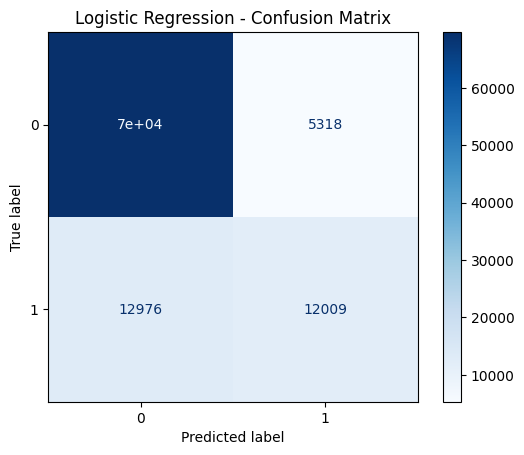

----- Random Forest -----
Accuracy: 0.84148
Precision: 0.7489777002344474
Recall: 0.5498098859315589
F1 Score: 0.6341226976873009

Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.94      0.90     75015
           1       0.75      0.55      0.63     24985

    accuracy                           0.84    100000
   macro avg       0.81      0.74      0.77    100000
weighted avg       0.83      0.84      0.83    100000



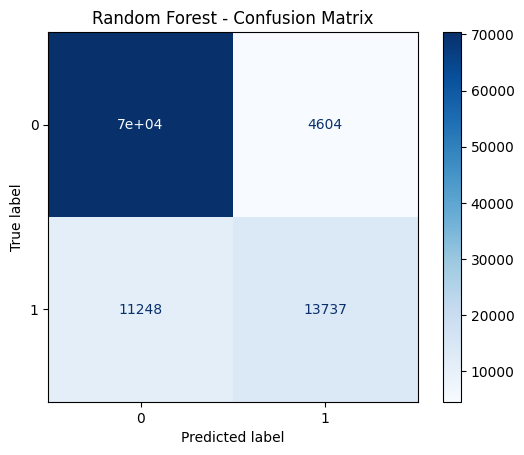

----- XGBoost -----
Accuracy: 0.86846
Precision: 0.9890863993385697
Recall: 0.47880728437062237
F1 Score: 0.6452535059331176

Classification Report:
               precision    recall  f1-score   support

           0       0.85      1.00      0.92     75015
           1       0.99      0.48      0.65     24985

    accuracy                           0.87    100000
   macro avg       0.92      0.74      0.78    100000
weighted avg       0.89      0.87      0.85    100000



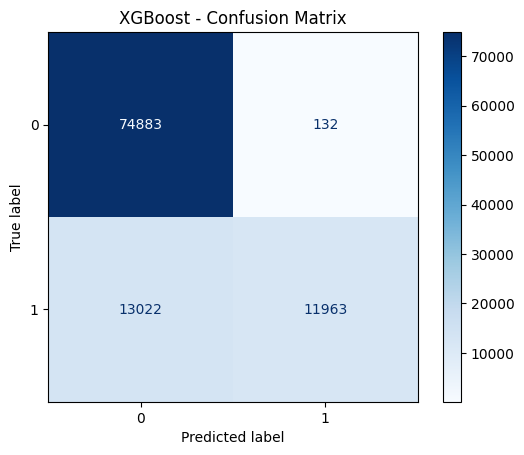

In [39]:
import matplotlib.pyplot as plt
def evaluate_model(name, y_true, y_pred):
    print(f"----- {name} -----")
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred))
    print("Recall:", recall_score(y_true, y_pred))
    print("F1 Score:", f1_score(y_true, y_pred))
    print("\nClassification Report:\n", classification_report(y_true, y_pred))
    
    # Plot confusion matrix
    disp = ConfusionMatrixDisplay.from_predictions(y_true, y_pred, cmap="Blues")
    disp.ax_.set_title(f"{name} - Confusion Matrix")
    plt.show()
evaluate_model("Logistic Regression", y_test, y_pred_lr)
evaluate_model("Random Forest", y_test, y_pred_rf)
evaluate_model("XGBoost", y_test, y_pred_xgb)

In [40]:
train_df.columns

Index(['country', 'hours_per_week', 'num_logins_last_month',
       'videos_watched_pct', 'assignments_submitted', 'discussion_posts',
       'is_working_professional', 'preferred_device', 'completed_course'],
      dtype='object')